In [1]:
import os
os.environ['LD_LIBRARY_PATH'] = '/usr/local/cuda/lib64:' + os.environ.get('LD_LIBRARY_PATH', '')


In [2]:
import os
print("LD_LIBRARY_PATH:", os.environ.get('LD_LIBRARY_PATH'))


LD_LIBRARY_PATH: /usr/local/cuda/lib64:


In [3]:
import tensorflow as tf
print("GPUs detected:", tf.config.list_physical_devices('GPU'))


2025-06-19 01:15:41.185408: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-19 01:15:41.224214: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750313741.247182   16629 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750313741.254207   16629 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750313741.287821   16629 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
import os
import datetime
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow import keras
from tensorflow.keras import layers, models #type: ignore
from tensorflow.keras.applications import ResNet50  #type: ignore
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator #type: ignore
from tensorflow.keras.utils import to_categorical #type: ignore
from tensorflow.keras.optimizers import Adam #type: ignore
from tensorflow.keras.optimizers.schedules import ExponentialDecay #type: ignore
from tensorflow.keras.regularizers import l2 #type: ignore
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau #type: ignore
from tensorflow.keras.metrics import AUC, Precision, Recall #type: ignore

In [5]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

In [6]:
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array

class ImageDataset:
    def __init__(self, data_dir, max_images_per_class=1500):
        self.data_dir = data_dir
        self.max_images_per_class = max_images_per_class 
        self.images = []
        self.labels = []
        self.class_names = ['hojas', 'otros', 'animales'] 
        
    def load_data(self):
        """Carga datos con validación mejorada y límite de imágenes"""
        total_images = 0
        class_counts = {}
        
        for idx, label in enumerate(self.class_names):
            label_dir = os.path.join(self.data_dir, label)
            if not os.path.exists(label_dir):
                print(f"Advertencia: no existe la carpeta {label_dir}")
                continue
                
            class_count = 0
            for image_name in os.listdir(label_dir):
                if not image_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                    continue
                    
                img_path = os.path.join(label_dir, image_name)
                img_array = self.load_and_preprocess_image(img_path)
                if img_array is not None:
                    self.images.append(img_array)
                    self.labels.append(idx)
                    class_count += 1
                    total_images += 1

                if class_count >= self.max_images_per_class:
                    print(f"Clase '{label}': Se han cargado el máximo de {self.max_images_per_class} imágenes.")
                    break
            
            class_counts[label] = class_count
            print(f"Clase '{label}': {class_count} imágenes")
        
        print(f"Total de imágenes cargadas: {total_images}")
        
        if class_counts:
            max_count = max(class_counts.values())
            min_count = min(class_counts.values())
            ratio = max_count / min_count if min_count > 0 else float('inf')
            
            if ratio > 3:
                print(f"Desbalance detectado: ratio {ratio:.2f}:1")
                print("Considera usar class_weight o data augmentation")
        
        return class_counts

    def load_and_preprocess_image(self, img_path):
        """Carga y preprocesa imagen con manejo de errores mejorado"""
        try:
            img = load_img(img_path, target_size=(224, 224))
            img_array = img_to_array(img) / 255.0
            return img_array
        except Exception as e:
            print(f"Error al cargar {img_path}: {e}")
            return None


In [7]:
print("Clasificador de Hojas")
print("=" * 50)

data_dir = 'data/'
dataset = ImageDataset(data_dir)
class_counts = dataset.load_data()

if not dataset.images:
    print("No se cargaron imágenes. Verifica la estructura de carpetas.")
    exit(1)

Clasificador de Hojas
Clase 'hojas': Se han cargado el máximo de 1500 imágenes.
Clase 'hojas': 1500 imágenes
Clase 'otros': Se han cargado el máximo de 1500 imágenes.
Clase 'otros': 1500 imágenes
Clase 'animales': Se han cargado el máximo de 1500 imágenes.
Clase 'animales': 1500 imágenes
Total de imágenes cargadas: 4500


In [8]:
images = np.array(dataset.images)
labels = np.array(dataset.labels)
labels_cat = to_categorical(labels, num_classes=3)

print(f"\nDatos preparados:")
print(f"Imágenes: {images.shape}")
print(f"Etiquetas: {labels_cat.shape}")


Datos preparados:
Imágenes: (4500, 224, 224, 3)
Etiquetas: (4500, 3)


In [9]:
X_train, X_val, y_train, y_val = train_test_split(
        images, labels_cat, 
        test_size=0.2, 
        random_state=42, 
        stratify=labels
    )

print(f"\nDivisión de datos:")
print(f"Entrenamiento: {X_train.shape[0]} imágenes")
print(f"Validación: {X_val.shape[0]} imágenes")


División de datos:
Entrenamiento: 3600 imágenes
Validación: 900 imágenes


In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=40,          # Rotación aleatoria de la imagen entre 0 y 40 grados
    width_shift_range=0.2,      # Desplazamiento horizontal aleatorio
    height_shift_range=0.2,     # Desplazamiento vertical aleatorio
    zoom_range=0.2,             # Zoom aleatorio
    horizontal_flip=True,       # Volteo horizontal aleatorio
    fill_mode='nearest'         # Estrategia para rellenar píxeles vacíos después de la transformación
)

In [11]:
train_generator = datagen.flow(
    X_train, y_train, 
    batch_size=16, 
    shuffle=True
)
valid_generator = ImageDataGenerator(rescale=1./255).flow(
    X_val, y_val, 
    batch_size=16, 
    shuffle=False
)


In [12]:
print(f"Generador de entrenamiento creado: {len(X_train)} imágenes base")
print(f"Generador de validación creado: {len(X_val)} imágenes")

print(f"\nDivisión de datos originales:")
print(f"Entrenamiento: {X_train.shape[0]} imágenes")
print(f"Validación: {X_val.shape[0]} imágenes")

Generador de entrenamiento creado: 3600 imágenes base
Generador de validación creado: 900 imágenes

División de datos originales:
Entrenamiento: 3600 imágenes
Validación: 900 imágenes


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau,
    ModelCheckpoint, TensorBoard
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.metrics import (
    Precision, Recall, AUC, F1Score
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

In [14]:
def modelo_base():
    """
    Crea el modelo base MobileNetV2 sin compilar (para fases)
    """
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,  
        weights='imagenet' 
    )
    
    # Crear arquitectura completa
    inputs = base_model.input 
    x = base_model.output 
    x = layers.GlobalAveragePooling2D()(x) 
    x = layers.Dropout(0.3)(x) 
    outputs = layers.Dense(3, activation='softmax', name='clasificador')(x) 
    
    modelo = Model(inputs=inputs, outputs=outputs)
    
    print(f"Número de capas en el modelo base: {len(base_model.layers)}")
    
    return modelo, base_model

modelo, base_model = modelo_base()

I0000 00:00:1750313779.979437   16629 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5578 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Número de capas en el modelo base: 154


In [15]:
def fase_1(modelo, base_model):

    print("CONFIGURANDO FASE 1: SOLO CLASIFICADOR")

    base_model.trainable = False
    

    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),  # Más agresivo
        loss='categorical_crossentropy',
        metrics=['accuracy', Precision(), Recall(), AUC()]
    )
    

    trainable_params = sum([tf.keras.backend.count_params(w) for w in modelo.trainable_weights])
    print(f"Parámetros entrenables FASE 1: {trainable_params:,}")
    
    return modelo

modelo = fase_1(modelo, base_model)


CONFIGURANDO FASE 1: SOLO CLASIFICADOR
Parámetros entrenables FASE 1: 3,843


In [16]:
def callbacks_fase_1():
    """
    Callbacks específicos para Fase 1 (más agresivos)
    """
    return [
        EarlyStopping(
            patience=5, 
            min_delta=0.001,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,  
            patience=2,
            min_lr=1e-5,
            verbose=1
        )
    ]

callbacks_1 = callbacks_fase_1()

In [17]:
def entrenar_fase(modelo, train_generator , valid_generator, callbacks, 
                  batch_size, epochs, fase_nombre):

    print(f"INICIANDO {fase_nombre}")
    
    history = modelo.fit(
        train_generator,
        validation_data=valid_generator,
        epochs=epochs,
        callbacks=callbacks,
        batch_size=batch_size,
        verbose=1
    )
    
    print(f"{fase_nombre} COMPLETADA")
    return history

In [18]:
historias = {}

BATCH_SIZE=16

historia_fase_1 = entrenar_fase(
        modelo, train_generator, valid_generator, 
        callbacks_1, BATCH_SIZE, epochs=5, 
        fase_nombre="FASE 1: SOLO CLASIFICADOR"
    )

INICIANDO FASE 1: SOLO CLASIFICADOR
Epoch 1/5


/home/juan0/Backend-Tesis/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1750313784.172265   16791 service.cc:152] XLA service 0x73aa2c002940 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750313784.172314   16791 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-06-19 01:16:24.245875: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1750313784.778497   16791 cuda_dnn.cc:529] Loaded cuDNN version 91001
2025-06-19 01:16:34.281647: E

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.8085 - auc: 0.9286 - loss: 0.4698 - precision: 0.8439 - recall: 0.7722

2025-06-19 01:17:00.791786: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1242', 84 bytes spill stores, 84 bytes spill loads

2025-06-19 01:17:01.111839: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1242', 1604 bytes spill stores, 1604 bytes spill loads

2025-06-19 01:17:05.768521: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1242', 120 bytes spill stores, 120 bytes spill loads

2025-06-19 01:17:06.332394: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1242', 1544 bytes spill stores, 1544 bytes spill loads

2025-06-19 01:17:13.431548: E 

225/225 ━━━━━━━━━━━━━━━━━━━━ 58s 181ms/step - accuracy: 0.8089 - auc: 0.9288 - loss: 0.4690 - precision: 0.8442 - recall: 0.7727 - val_accuracy: 0.3333 - val_auc: 0.5097 - val_loss: 1.2673 - val_precision: 0.3333 - val_recall: 0.3333 - learning_rate: 0.0010
Epoch 2/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 18s 79ms/step - accuracy: 0.9541 - auc: 0.9953 - loss: 0.1269 - precision: 0.9599 - recall: 0.9520 - val_accuracy: 0.3333 - val_auc: 0.5102 - val_loss: 1.2129 - val_precision: 0.3333 - val_recall: 0.3333 - learning_rate: 0.0010
Epoch 3/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 20s 89ms/step - accuracy: 0.9631 - auc: 0.9964 - loss: 0.1081 - precision: 0.9637 - recall: 0.9606 - val_accuracy: 0.3333 - val_auc: 0.5133 - val_loss: 1.1645 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 17s 76ms/step - accuracy: 0.9632 - auc: 0.9975 - loss: 0.0895 - precision: 0.9647 - recall: 0.9627 - val_accuracy: 0.3333 - val_auc: 0.5146 - val_loss: 1.4230 - 

In [19]:
resultados = modelo.evaluate(X_val, y_val, verbose=1)
val_loss = resultados[0]
val_acc = resultados[1]
print(f"Validation Accuracy después de Fase 1: {val_acc:.4f}")
print(f"Validation Loss después de Fase 1: {val_loss:.4f}")

2025-06-19 01:18:37.310705: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1237', 212 bytes spill stores, 212 bytes spill loads

2025-06-19 01:18:37.407885: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1237', 84 bytes spill stores, 84 bytes spill loads

2025-06-19 01:18:37.772129: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1237', 6096 bytes spill stores, 6052 bytes spill loads

2025-06-19 01:18:37.789182: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1237', 1604 bytes spill stores, 1604 bytes spill loads

2025-06-19 01:18:46.408014: E 

29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 142ms/step - accuracy: 0.9828 - auc: 0.9993 - loss: 0.0538 - precision: 0.9827 - recall: 0.9809
Validation Accuracy después de Fase 1: 0.9744
Validation Loss después de Fase 1: 0.0675


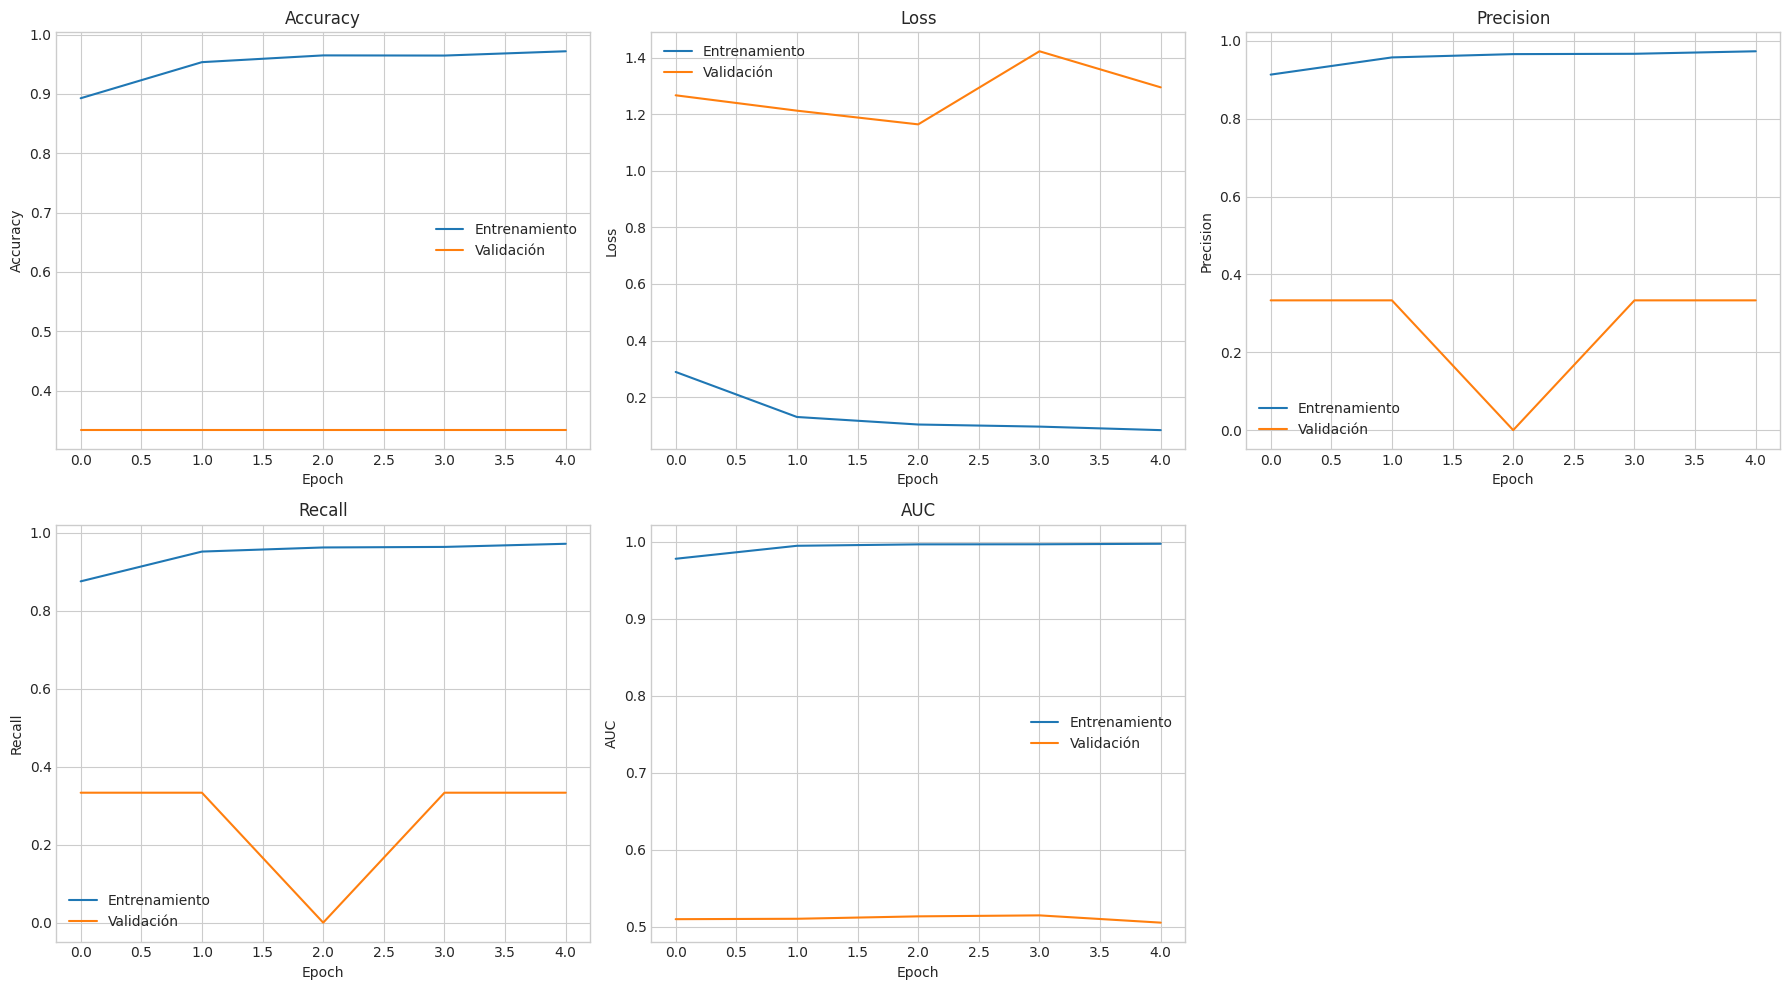

In [20]:

def visualizar_resultados(history):
    """
    Visualiza las métricas de entrenamiento.
    """
    acc_key = [k for k in history.history.keys() if 'accuracy' in k and 'val' not in k][0]
    val_acc_key = [k for k in history.history.keys() if 'accuracy' in k and 'val' in k][0]
    loss_key = [k for k in history.history.keys() if 'loss' in k and 'val' not in k][0]
    val_loss_key = [k for k in history.history.keys() if 'loss' in k and 'val' in k][0]
    precision_key = [k for k in history.history.keys() if 'precision' in k and 'val' not in k][0]
    val_precision_key = [k for k in history.history.keys() if 'precision' in k and 'val' in k][0]
    recall_key = [k for k in history.history.keys() if 'recall' in k and 'val' not in k][0]
    val_recall_key = [k for k in history.history.keys() if 'recall' in k and 'val' in k][0]
    auc_key = [k for k in history.history.keys() if 'auc' in k and 'val' not in k][0]
    val_auc_key = [k for k in history.history.keys() if 'auc' in k and 'val' in k][0]

    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(18, 10))

    plt.subplot(2, 3, 1)
    plt.plot(history.history[acc_key], label='Entrenamiento')
    plt.plot(history.history[val_acc_key], label='Validación')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(2, 3, 2)
    plt.plot(history.history[loss_key], label='Entrenamiento')
    plt.plot(history.history[val_loss_key], label='Validación')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(2, 3, 3)
    plt.plot(history.history[precision_key], label='Entrenamiento')
    plt.plot(history.history[val_precision_key], label='Validación')
    plt.title('Precision')
    plt.xlabel('Epoch')
    plt.ylabel('Precision')
    plt.legend()

    plt.subplot(2, 3, 4)
    plt.plot(history.history[recall_key], label='Entrenamiento')
    plt.plot(history.history[val_recall_key], label='Validación')
    plt.title('Recall')
    plt.xlabel('Epoch')
    plt.ylabel('Recall')
    plt.legend()

    plt.subplot(2, 3, 5)
    plt.plot(history.history[auc_key], label='Entrenamiento')
    plt.plot(history.history[val_auc_key], label='Validación')
    plt.title('AUC')
    plt.xlabel('Epoch')
    plt.ylabel('AUC')
    plt.legend()

    plt.tight_layout()
    plt.show()

visualizar_resultados(historia_fase_1)

29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 256ms/step


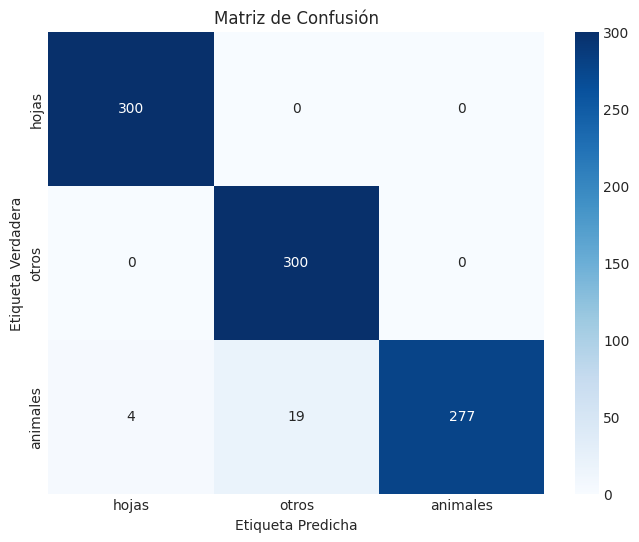

In [21]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_probs = modelo.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val, axis=1)
cm = confusion_matrix(y_true, y_pred)
class_names = ['hojas', 'otros', 'animales']

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Verdadera')
plt.title('Matriz de Confusión')
plt.show()


2025-06-19 01:19:11.513465: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-06-19 01:19:11.678675: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-06-19 01:19:11.845729: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


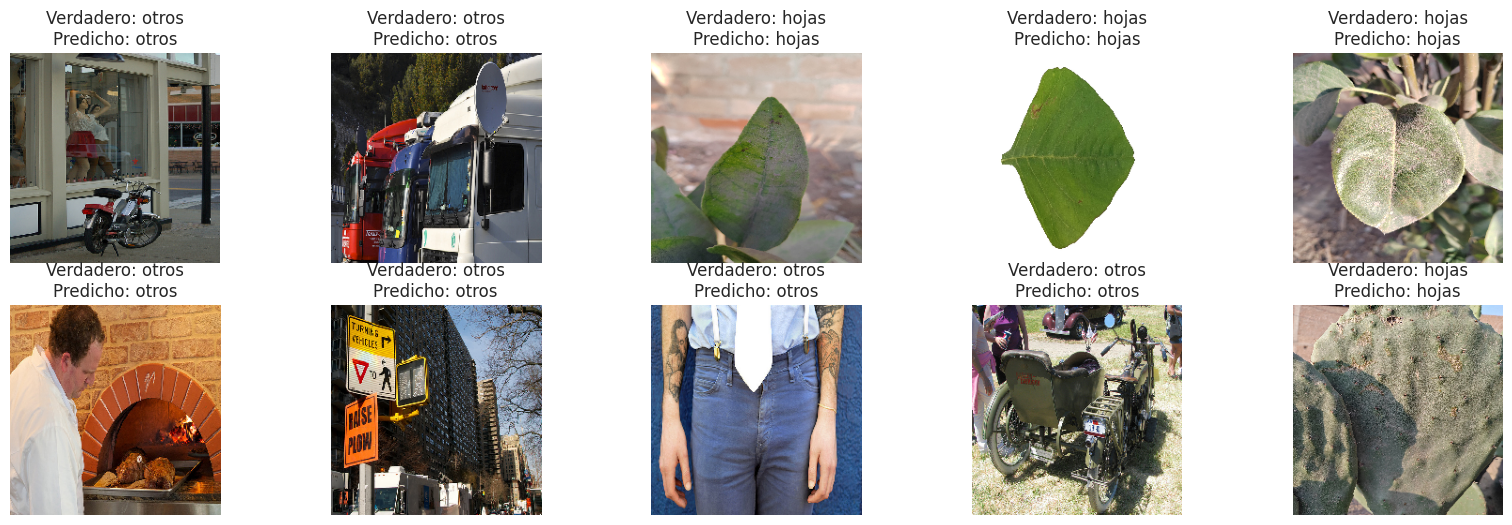

In [22]:
import random
import matplotlib.pyplot as plt
import numpy as np


indices = random.sample(range(len(X_val)), 10)

class_names = ['hojas', 'otros', 'animales']

plt.figure(figsize=(20, 6))

for i, idx in enumerate(indices):
    img = X_val[idx]
    true_label = np.argmax(y_val[idx])
    
    img_input = np.expand_dims(img, axis=0)
    pred_probs = modelo.predict(img_input)
    pred_label = np.argmax(pred_probs[0])
    
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Verdadero: {class_names[true_label]}\nPredicho: {class_names[pred_label]}")
    
plt.show()




In [23]:
def fase_2(modelo, base_model, fine_tune_at=114):
    """
    FASE 2: Descongelar últimas capas del backbone + clasificador
    """

    print(f"CONFIGURANDO FASE 2: BACKBONE (desde capa {fine_tune_at}) + CLASIFICADOR")

    

    base_model.trainable = True
    

    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False
    
    print(f"Capas de la 1 a la {fine_tune_at} congeladas.")
    print(f"Capas de la {fine_tune_at} en adelante entrenables.")
    

    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy', Precision(), Recall(), AUC()]
    )
    

    trainable_params = sum([tf.keras.backend.count_params(w) for w in modelo.trainable_weights])
    print(f"Parámetros entrenables FASE 2: {trainable_params:,}")
    
    return modelo

modelo_2 = fase_2(modelo, base_model, fine_tune_at=114)

CONFIGURANDO FASE 2: BACKBONE (desde capa 114) + CLASIFICADOR
Capas de la 1 a la 114 congeladas.
Capas de la 114 en adelante entrenables.
Parámetros entrenables FASE 2: 1,685,379


In [24]:
def callbacks_fase_2():
    """
    Callbacks específicos para Fase 2 (más conservadores)
    """
    return [
        EarlyStopping(
            patience=4,
            min_delta=0.0001,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        )
    ]

callbacks_2 = callbacks_fase_2()

In [28]:
historia_fase_2 = modelo_2.fit(
        train_generator,
        validation_data=valid_generator,
        initial_epoch=historia_fase_1.epoch[-1],
        epochs=10,
        callbacks=callbacks_2,
        batch_size=BATCH_SIZE,
        verbose=1
    )

historias['fase_1'] = historia_fase_1
historias['fase_2'] = historia_fase_2

Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 17s 76ms/step - accuracy: 0.9808 - auc_1: 0.9989 - loss: 0.0611 - precision_1: 0.9813 - recall_1: 0.9803 - val_accuracy: 0.3333 - val_auc_1: 0.4872 - val_loss: 2.4045 - val_precision_1: 0.3333 - val_recall_1: 0.3333 - learning_rate: 2.5000e-05
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - accuracy: 0.9837 - auc_1: 0.9986 - loss: 0.0542 - precision_1: 0.9850 - recall_1: 0.9810 - val_accuracy: 0.3378 - val_auc_1: 0.4902 - val_loss: 2.2855 - val_precision_1: 0.3386 - val_recall_1: 0.3356 - learning_rate: 2.5000e-05
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 17s 77ms/step - accuracy: 0.9701 - auc_1: 0.9981 - loss: 0.0724 - precision_1: 0.9730 - recall_1: 0.9689 - val_accuracy: 0.3333 - val_auc_1: 0.5235 - val_loss: 1.1799 - val_precision_1: 0.3394 - val_recall_1: 0.3322 - learning_rate: 2.5000e-05
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 20s 88ms/step - accuracy: 0.9818 - auc_1: 0.9987 - loss: 0.0534 - precision_1: 0.9819 - recall_1: 0.9811 - v

In [ ]:
resultados = modelo_2.evaluate(valid_generator, verbose=1)
val_loss = resultados[0]
val_acc = resultados[1]
print(f"Validation Accuracy después de Fase 1: {val_acc:.4f}")
print(f"Validation Loss después de Fase 1: {val_loss:.4f}")

29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.9952 - auc_3: 0.9999 - loss: 0.0187 - precision_3: 0.9952 - recall_3: 0.9952
Validation Accuracy después de Fase 1: 0.9933
Validation Loss después de Fase 1: 0.0254


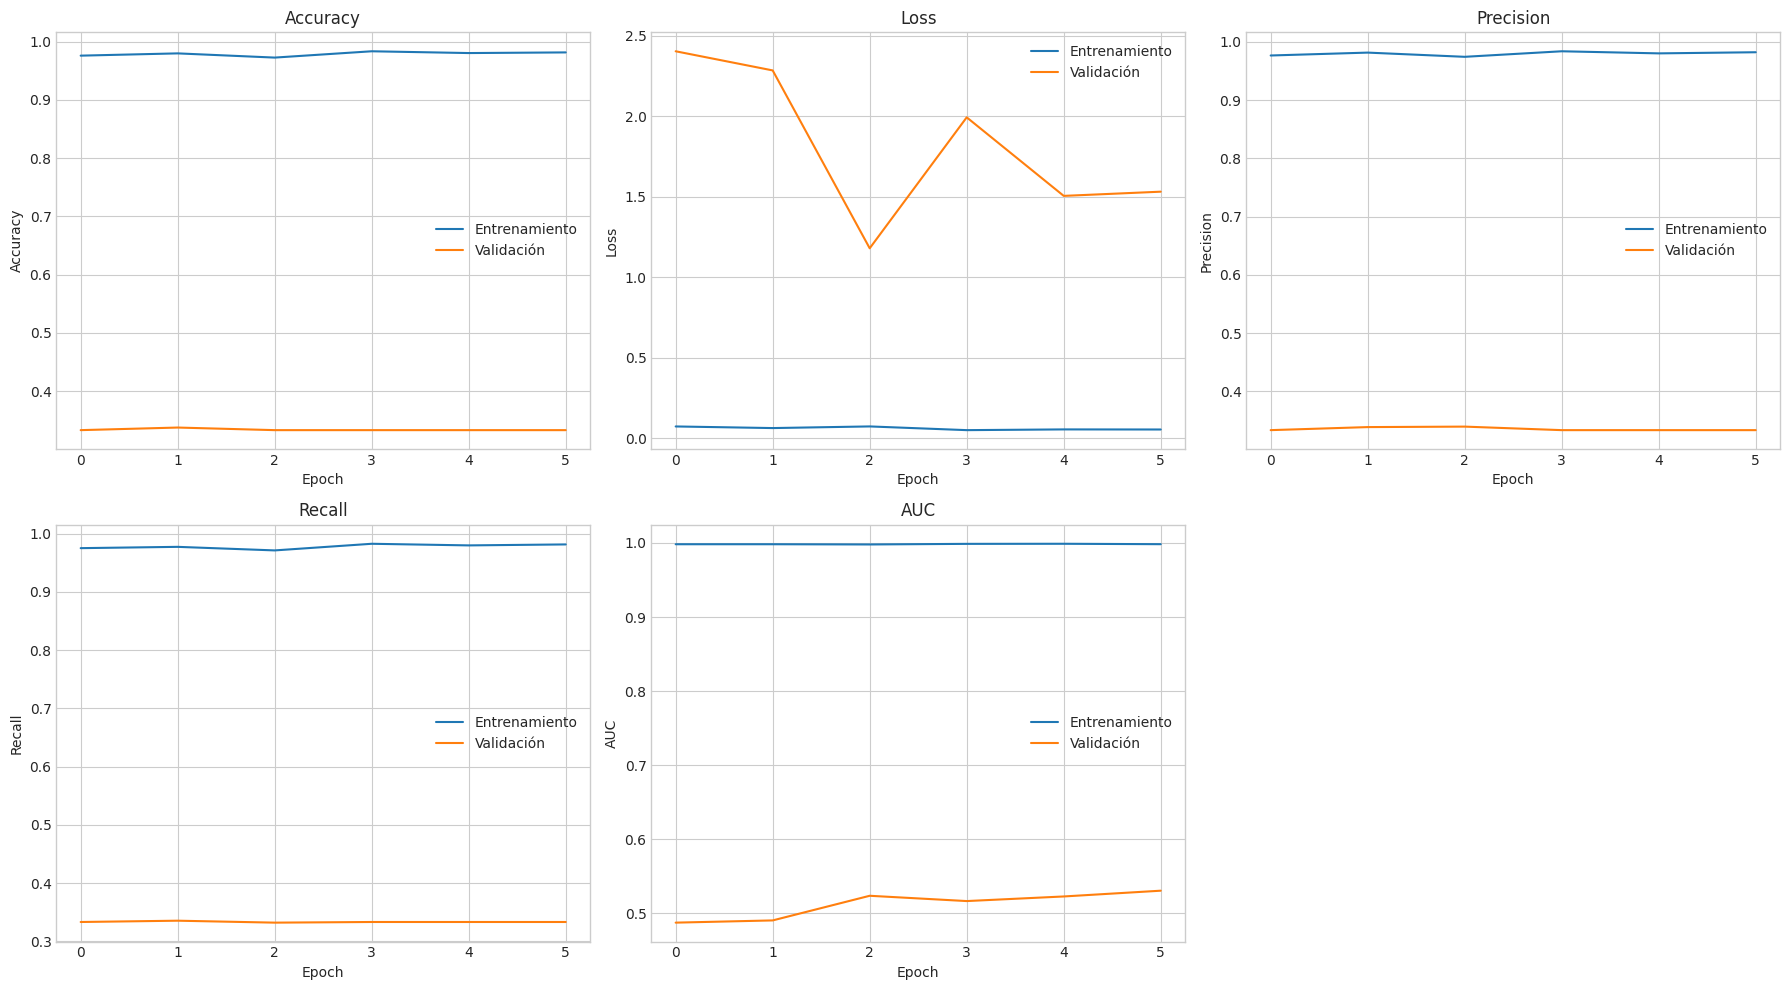

In [29]:

def visualizar_resultados(history):
    """
    Visualiza las métricas de entrenamiento.
    """
    acc_key = [k for k in history.history.keys() if 'accuracy' in k and 'val' not in k][0]
    val_acc_key = [k for k in history.history.keys() if 'accuracy' in k and 'val' in k][0]
    loss_key = [k for k in history.history.keys() if 'loss' in k and 'val' not in k][0]
    val_loss_key = [k for k in history.history.keys() if 'loss' in k and 'val' in k][0]
    precision_key = [k for k in history.history.keys() if 'precision' in k and 'val' not in k][0]
    val_precision_key = [k for k in history.history.keys() if 'precision' in k and 'val' in k][0]
    recall_key = [k for k in history.history.keys() if 'recall' in k and 'val' not in k][0]
    val_recall_key = [k for k in history.history.keys() if 'recall' in k and 'val' in k][0]
    auc_key = [k for k in history.history.keys() if 'auc' in k and 'val' not in k][0]
    val_auc_key = [k for k in history.history.keys() if 'auc' in k and 'val' in k][0]

    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(18, 10))

    plt.subplot(2, 3, 1)
    plt.plot(history.history[acc_key], label='Entrenamiento')
    plt.plot(history.history[val_acc_key], label='Validación')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(2, 3, 2)
    plt.plot(history.history[loss_key], label='Entrenamiento')
    plt.plot(history.history[val_loss_key], label='Validación')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(2, 3, 3)
    plt.plot(history.history[precision_key], label='Entrenamiento')
    plt.plot(history.history[val_precision_key], label='Validación')
    plt.title('Precision')
    plt.xlabel('Epoch')
    plt.ylabel('Precision')
    plt.legend()

    plt.subplot(2, 3, 4)
    plt.plot(history.history[recall_key], label='Entrenamiento')
    plt.plot(history.history[val_recall_key], label='Validación')
    plt.title('Recall')
    plt.xlabel('Epoch')
    plt.ylabel('Recall')
    plt.legend()

    plt.subplot(2, 3, 5)
    plt.plot(history.history[auc_key], label='Entrenamiento')
    plt.plot(history.history[val_auc_key], label='Validación')
    plt.title('AUC')
    plt.xlabel('Epoch')
    plt.ylabel('AUC')
    plt.legend()

    plt.tight_layout()
    plt.show()

visualizar_resultados(historia_fase_2)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


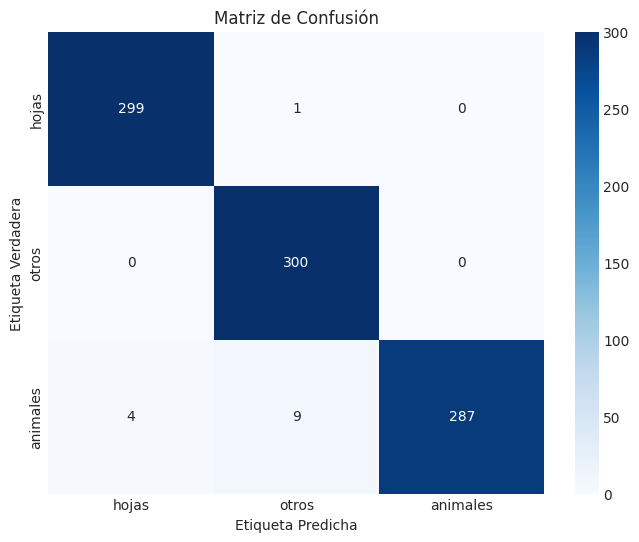

In [32]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_probs = modelo_2.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val, axis=1)
cm = confusion_matrix(y_true, y_pred)
class_names = ['hojas', 'otros', 'animales']

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Verdadera')
plt.title('Matriz de Confusión')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


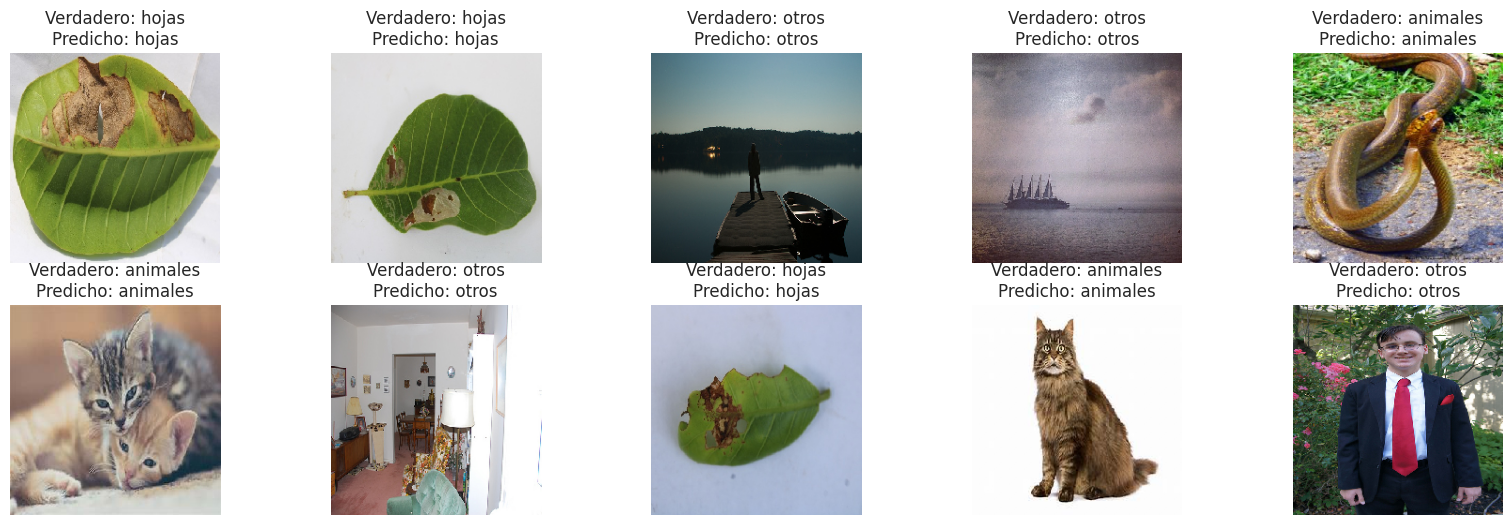

In [33]:
import random
import matplotlib.pyplot as plt
import numpy as np


indices = random.sample(range(len(X_val)), 10)

class_names = ['hojas', 'otros', 'animales']

plt.figure(figsize=(20, 6))

for i, idx in enumerate(indices):
    img = X_val[idx]
    true_label = np.argmax(y_val[idx])
    
    img_input = np.expand_dims(img, axis=0)
    pred_probs = modelo_2.predict(img_input)
    pred_label = np.argmax(pred_probs[0])
    
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Verdadero: {class_names[true_label]}\nPredicho: {class_names[pred_label]}")
    
plt.show()




In [ ]:
modelo_2.save("modelo_hojas_multiclasev4.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


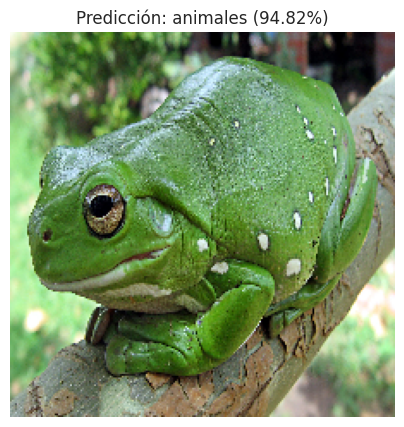

Shape de la imagen procesada: (224, 224, 3)
Predicción cruda (probabilidades): [0.04118133 0.01064345 0.9481752 ]
Predicción final: animales con probabilidad 0.9482


In [ ]:
from tensorflow.keras.models import load_model #type: ignore
from tensorflow.keras.preprocessing import image #type: ignore

modelo_cargado = load_model('modelo_hojas_multiclasev4.h5')
img_path = '../Huevo/image.png'
clases = ['hojas', 'otros', 'animales']

img = image.load_img(img_path, target_size=(224, 224))

img_array = image.img_to_array(img)

img_array_expanded = np.expand_dims(img_array, axis=0) / 255.0

prediccion = modelo_cargado.predict(img_array_expanded)

indice_clase = np.argmax(prediccion[0])

etiqueta_predicha = clases[indice_clase]
probabilidad = prediccion[0][indice_clase]

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis('off')
plt.title(f"Predicción: {etiqueta_predicha} ({probabilidad:.2%})")
plt.show()

print(f"Shape de la imagen procesada: {img_array.shape}")
print(f"Predicción cruda (probabilidades): {prediccion[0]}")
print(f"Predicción final: {etiqueta_predicha} con probabilidad {probabilidad:.4f}")